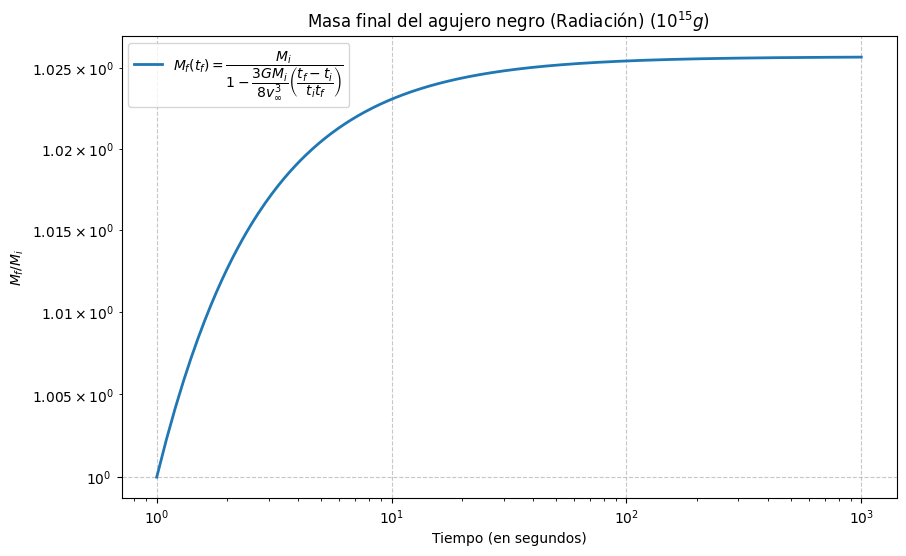

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definir el dominio (eje X)

G=6.674*10**-11 #N*m^2 /kg^2
Mi=1e30 #kg
Vi=1e7 #m/s
ti=1 #s
# np.linspace(inicio, fin, número_de_puntos)
t = np.linspace(ti, 1e3, 10000)
k=(3*G*Mi)/(8*Vi**3)
p=1 - k * ( (1/ti) - (1/t) )
# 2. Definir la función (eje Y)
# Puedes cambiar esto por: x**2, np.exp(x), np.tan(x), etc.
M = np.divide(Mi, p, out=np.full_like(p, np.nan), where=p!=0)
etiqueta_ecuacion = r'$M_{f}(t_{f})=\dfrac{M_{i}}{1-\dfrac{3GM_{i}}{8v_{\infty}^{3}}\left(\dfrac{t_{f}-t_{i}}{t_{i}t_{f}} \right)}$'
# 3. Crear la figura y graficar
plt.figure(figsize=(10, 6))  # Tamaño de la figura en pulgadas
plt.loglog(t, M/Mi, label=etiqueta_ecuacion, color='#1f77b4', linewidth=2)

# 4. Personalización (Estilo académico/científico)
plt.title('Masa final del agujero negro (Radiación) ($10^{15} g$)')
plt.xlabel('Tiempo (en segundos)')
plt.ylabel(r'$M_{f}/M_{i}$')

# Añadir ejes cruzados en el origen (0,0)
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# Añadir rejilla y leyenda
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.savefig("Radsin.pdf")

plt.show()

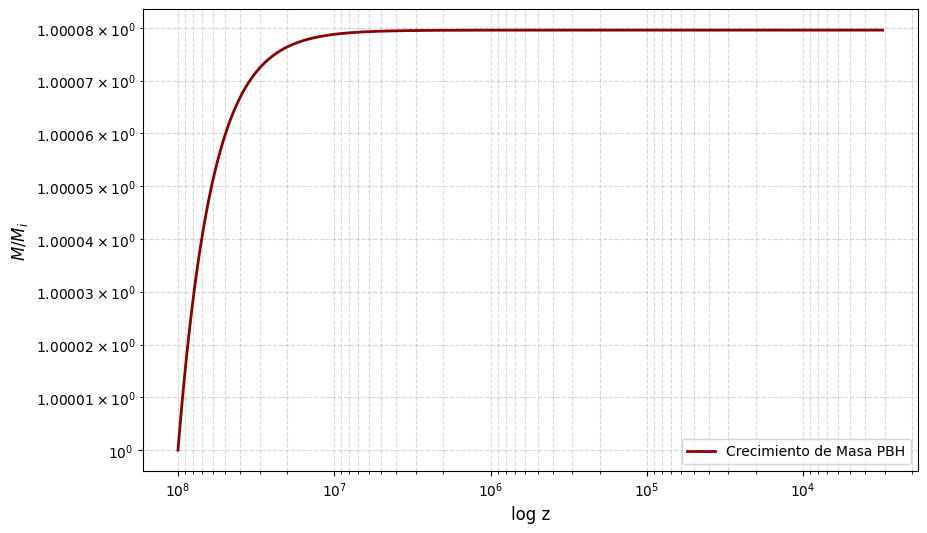

In [29]:
import numpy as np
import matplotlib.pyplot as plt
#Hecho con Gemini

# 1. Constantes Físicas (Unidades SI)
G = 6.67430e-11        # 
c = 2.998e8        #
M_sol = 1.989e33    # 
H0_km_s_Mpc = 67.4    # Constante de Hubble (Planck 2018)
H0 = H0_km_s_Mpc * 1000 / 3.086e22  # Convertir a 1/s (SI)
Omega_r0 = 9.0e-5     # Densidad de radiación hoy (aprox)  # g/cm^3 (Densidad radiación actual aprox) - Ajustar según modelo

# Parámetros del Agujero Negro y el Medio
M_i = 20*M_sol        # Masa inicial (Kg) - PBH típico
v_inf = c / np.sqrt(3) # Velocidad del sonido en era de radiación (c/sqrt(3))

# Redshift Inicial (Formación del PBH)
z_i = 1e8           # Muy temprano en el universo

# 2. Definir Constantes Agrupadas
# Constante C^2 derivada de la relación t-z
# C^2 = sqrt(32 pi G rho_r0 / 3)
C_sq = np.sqrt((H0**2)*Omega_r0)

# Constante de Acreción K = 3 G M_i / 8 v_inf^3
K_acc = (3 * G * M_i) / (4 * v_inf**3)

# Factor total combinado para limpiar la fórmula
Factor = K_acc * C_sq

# 3. Dominio del Redshift
# Vamos desde z_i (pasado) hasta z_f (futuro, menor z)
# Usamos escala logarítmica porque el redshift abarca muchos órdenes de magnitud
z = np.geomspace(z_i, 3100, 500) 

# 4. Ecuación M(z)
# El término es Factor * [ (1+zi)^2 - (1+z)^2 ]
denominador = 1 - Factor * ( (1+z_i)**2 - (1+z)**2 )

# Calcular masa protegiendo contra singularidades
M_z = np.divide(M_i, denominador, out=np.full_like(denominador, np.nan), where=denominador!=0)

# 5. Graficar
plt.figure(figsize=(10, 6))

# Nota: Invertimos el eje X para mostrar la flecha del tiempo (Pasado -> Futuro)
plt.loglog(z, M_z/M_i, color='darkred', linewidth=2, label='Crecimiento de Masa PBH')


plt.gca().invert_xaxis() # Invertir eje X: z alto (izquierda) -> z bajo (derecha)

#plt.title(f'Acreción de PBH en función del Redshift ($z_i = 10^8$)', fontsize=14)
plt.xlabel('log z', fontsize=12)
plt.ylabel('$M/M_{i}$', fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.savefig("accret.pdf")
plt.show()

<>:116: SyntaxWarning: invalid escape sequence '\l'
<>:116: SyntaxWarning: invalid escape sequence '\l'
C:\Users\jaosi\AppData\Local\Temp\ipykernel_23340\1096162602.py:116: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel(' $\log z$', fontsize=12)


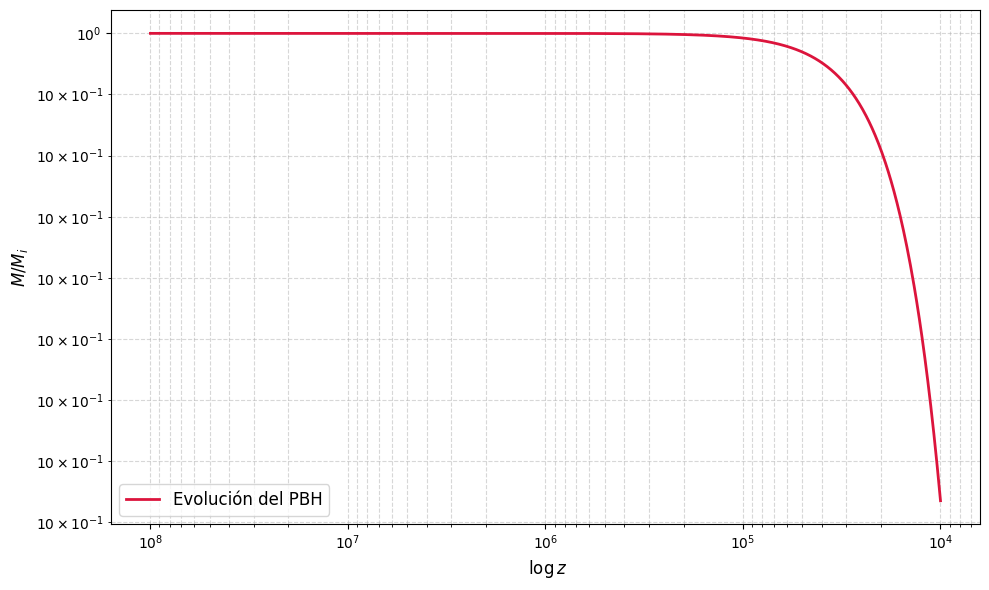

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
#Caso de radiación
# ---------------------------------------------------------
# 1. Definición de Constantes Físicas (Sistema Internacional)
# ---------------------------------------------------------
G = 6.67430e-11       # Constante gravitacional (m^3 kg^-1 s^-2)
c = 2.99792e8         # Velocidad de la luz (m/s)
hbar = 1.05457e-34    # Constante de Planck reducida (J s)

# Constantes Cosmológicas
H0_km_s_Mpc = 67.4    # Constante de Hubble (Planck 2018)
# Conversión de H0 a unidades 1/s:
# 1 Mpc = 3.0857e22 m, 1 km = 1000 m
H0 = (H0_km_s_Mpc * 1000) / 3.0857e22 
Omega_r0 = 9.0e-5     # Densidad de radiación actual (aprox)

# Velocidad del sonido en el plasma (Era de radiación)
v_inf = c / np.sqrt(3)

# ---------------------------------------------------------
# 2. Definición de la Ecuación Diferencial (0.5.18)
# ---------------------------------------------------------
def dMdz(z, M):
    """
    Representa la ecuación 0.5.18 de la imagen proporcionada.
    dM/dz = Término_Evaporación - Término_Acreción
    """
    if M <= 1e-5: return 0  # Si la masa es casi 0, el BH desapareció
    
    # Pre-cálculo de términos comunes para legibilidad
    sqrt_Wr0 = np.sqrt(Omega_r0)
    term_z = (1 + z)
    
    # --- TÉRMINO 1: Evaporación (Hawking) ---
    # Numerador: hbar * c^4
    # Denominador: 3840 * pi * G^2 * M^2 * sqrt(Wr0) * H0 * (1+z)^3
    num_evap = hbar * c**4
    den_evap = 3840 * np.pi * G**2 * M**2 * sqrt_Wr0 * H0 * (term_z**3)
    term_evap = num_evap / den_evap
    
    # --- TÉRMINO 2: Acreción (Bondi) ---
    # Numerador: G * M^2 * sqrt(Wr0) * H0 * (1+z)
    # Denominador: 2 * v_inf^3
    num_acc = G * M**2 * sqrt_Wr0 * H0 * term_z
    den_acc = 2 * v_inf**3
    term_acc = num_acc / den_acc
    
    return term_evap - term_acc

# ---------------------------------------------------------
# 3. Método Runge-Kutta de Orden 4 (RK4)
# ---------------------------------------------------------
def solve_rk4(func, z_start, z_end, M0, num_steps):
    # Generamos los pasos de z (serán decrecientes)
    z_values = np.linspace(z_start, z_end, num_steps)
    M_values = np.zeros(num_steps)
    
    # Calculamos el tamaño del paso h
    h = (z_end - z_start) / (num_steps - 1)
    
    M_values[0] = M0
    M = M0
    
    for i in range(num_steps - 1):
        z = z_values[i]
        
        if M <= 1e-5: # Detener si se evapora
            M_values[i+1:] = 0
            break
        
        # Coeficientes RK4
        k1 = h * func(z, M)
        k2 = h * func(z + 0.5 * h, M + 0.5 * k1)
        k3 = h * func(z + 0.5 * h, M + 0.5 * k2)
        k4 = h * func(z + h, M + k3)
        
        # Actualización
        M = M + (k1 + 2*k2 + 2*k3 + k4) / 6.0
        M_values[i+1] = M
        
    return z_values, M_values

# ---------------------------------------------------------
# 4. Parámetros de Simulación y Ejecución
# ---------------------------------------------------------
# Redshift inicial (Muy temprano, cerca del Big Bang)
z_i = 1e8   
# Redshift final (Antes de la igualdad materia-radiación z~3400)
z_f = 1e4   

# Masa inicial crítica (10^12 kg = 10^15 g)
M_i = 1.0e12 

# Número de pasos (Alto para mantener precisión en rango grande de z)
steps = 50000

# Resolver
z_sol, M_sol = solve_rk4(dMdz, z_i, z_f, M_i, steps)

# ---------------------------------------------------------
# 5. Gráfica
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

# Graficamos Masa vs Redshift
plt.loglog(z_sol, M_sol/M_i, color='crimson', linewidth=2, label=r'Evolución del PBH')

# Configuración de ejes


# INVERTIR EJE X: Para que el tiempo fluya de izquierda (pasado, z alto) a derecha (futuro, z bajo)
plt.gca().invert_xaxis()

#plt.title(f'Evolución de PBH en Era de Radiación (Ec. 0.5.18)\n$M_i = 10^{{12}}$ kg', fontsize=14)
plt.xlabel(' $\log z$', fontsize=12)
plt.ylabel('$M/M_{i}$', fontsize=12)
plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

<>:98: SyntaxWarning: invalid escape sequence '\l'
<>:98: SyntaxWarning: invalid escape sequence '\l'
C:\Users\jaosi\AppData\Local\Temp\ipykernel_23340\2528414596.py:98: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel(' $\log z$', fontsize=12)


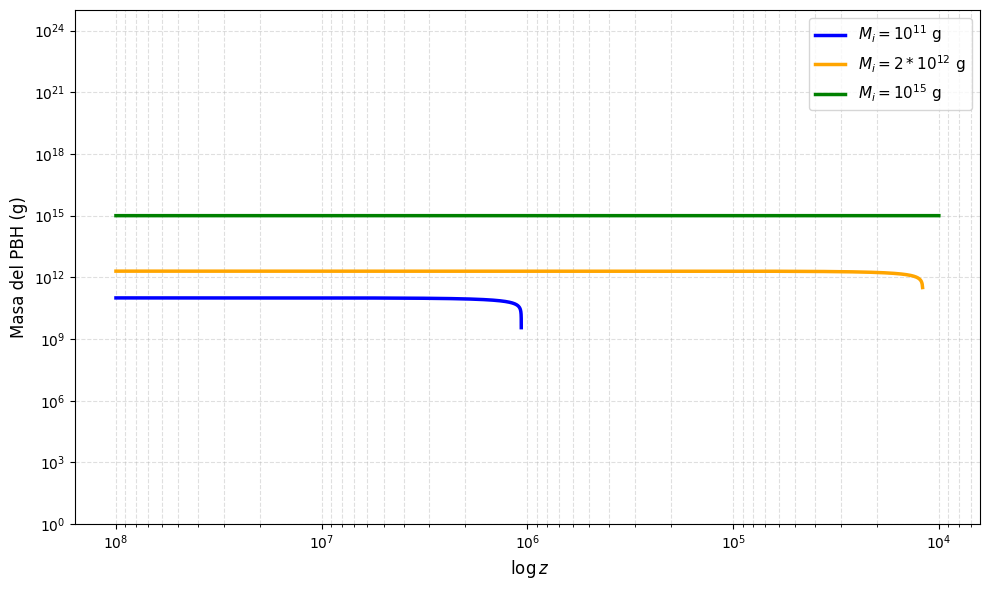

In [51]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Constantes y Parámetros (Sistema CGS: cm, g, s)
# ---------------------------------------------------------
G = 6.67430e-8        # cm^3 g^-1 s^-2
c = 2.99792e10        # cm/s
hbar = 1.05457e-27    # erg s (g cm^2 s^-1)

# Cosmología
H0_km_s_Mpc = 67.4
# Conversión H0 a 1/s:
# 1 Mpc = 3.0857e24 cm, 1 km = 10^5 cm
H0 = (H0_km_s_Mpc * 1e5) / 3.0857e24 
Omega_r0 = 9.0e-5
v_inf = c / np.sqrt(3) # cm/s

# ---------------------------------------------------------
# 2. Ecuación Diferencial dM/dz
# ---------------------------------------------------------
def dMdz(z, M):
    if M <= 1e-3 or np.isnan(M): return 0 
    
    sqrt_Wr0 = np.sqrt(Omega_r0)
    term_z = (1 + z)
    
    # Término Evaporación (Hawking)
    # Como todo está en CGS, el resultado será consistente
    num_evap = hbar * c**4
    den_evap = 3840 * np.pi * G**2 * M**2 * sqrt_Wr0 * H0 * (term_z**3)
    term_evap = num_evap / den_evap
    
    # Término Acreción (Bondi)
    num_acc = G * M**2 * sqrt_Wr0 * H0 * term_z
    den_acc = 2 * v_inf**3
    term_acc = num_acc / den_acc
    
    return term_evap - term_acc

# ---------------------------------------------------------
# 3. Solucionador RK4 (Con corte por evaporación)
# ---------------------------------------------------------
def solve_rk4(func, z_start, z_end, M0, num_steps):
    z_values = np.linspace(z_start, z_end, num_steps)
    M_values = np.full(num_steps, np.nan) # Inicializamos con NaN
    
    h = (z_end - z_start) / (num_steps - 1)
    
    M_values[0] = M0
    M = M0
    
    for i in range(num_steps - 1):
        z = z_values[i]
        
        # CONDICIÓN DE CORTE (en gramos)
        # Si la masa baja de 1 gramo (algo insignificante para un BH), cortamos.
        if M <= 1.0: 
            break 
            
        k1 = h * func(z, M)
        k2 = h * func(z + 0.5 * h, M + 0.5 * k1)
        k3 = h * func(z + 0.5 * h, M + 0.5 * k2)
        k4 = h * func(z + h, M + k3)
        
        M = M + (k1 + 2*k2 + 2*k3 + k4) / 6.0
        
        if M > 0:
            M_values[i+1] = M
        else:
            break
        
    return z_values, M_values


z_i = 1e8   
z_f = 1e4   
steps = 2000000


masas_iniciales_g = [1.0e11, 2e12, 1.0e15] 

colores = ['blue', 'orange', 'green']
labels = [r'$M_i = 10^{11}$ g ', 
          r'$M_i = 2*10^{12}$ g ', 
          r'$M_i = 10^{15}$ g']

plt.figure(figsize=(10, 6))

for M_i, color, label in zip(masas_iniciales_g, colores, labels):
    z_sol, M_sol = solve_rk4(dMdz, z_i, z_f, M_i, steps)
    
    plt.loglog(z_sol, M_sol, color=color, linewidth=2.5, label=label)

# Estética
plt.gca().invert_xaxis()
#plt.title(r'Evolución de la Masa de PBHs', fontsize=14)
plt.xlabel(' $\log z$', fontsize=12)
plt.ylabel('Masa del PBH (g)', fontsize=12)

plt.grid(True, which="both", linestyle='--', alpha=0.4)
plt.legend(fontsize=11)


plt.ylim(1, 1e25) 

plt.tight_layout()
plt.savefig("accrad1.pdf")
plt.show()

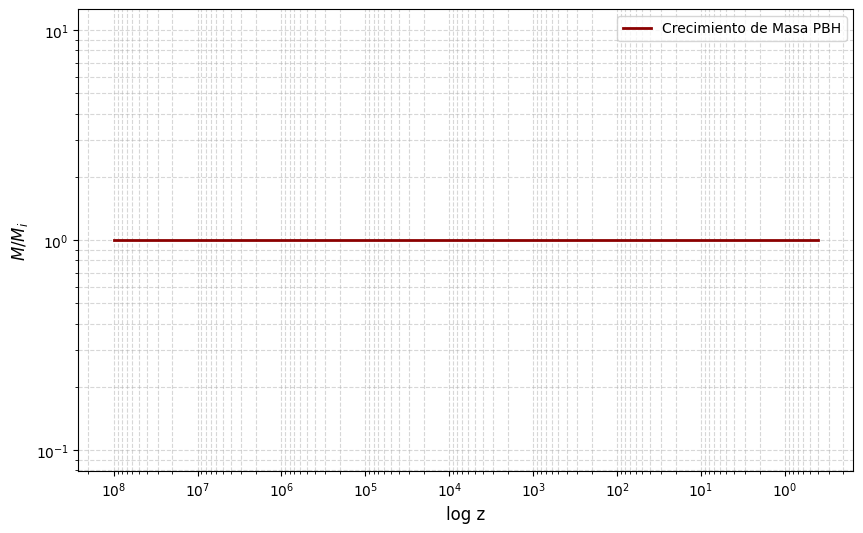

In [12]:
import numpy as np
import matplotlib.pyplot as plt
#Hecho con Gemini
#Caso de materia
# 1. Constantes Físicas (Unidades SI)
G = 6.67430e-11        # 
c = 2.998e8        #
M_sol = 1.989e33    # 
H0_km_s_Mpc = 67.4    # Constante de Hubble (Planck 2018)
H0 = H0_km_s_Mpc * 1000 / 3.086e22  # Convertir a 1/s (SI)
Omega_m0 = 0.315     # Densidad de materia (aprox)  # g/cm^3 (Densidad radiación actual aprox) - Ajustar según modelo

# Parámetros del Agujero Negro y el Medio
M_i = 1e15        # Masa inicial (Kg) - PBH típico
v_inf = c / np.sqrt(3) # Velocidad del sonido en era de radiación (c/sqrt(3))

# Redshift Inicial (Formación del PBH)
z_i = 1e8           # Muy temprano en el universo

# 2. Definir Constantes Agrupadas
# Constante C^2 derivada de la relación t-z
# C^2 = sqrt(32 pi G rho_r0 / 3)
C_sq = np.sqrt((H0**2)*Omega_m0)

# Constante de Acreción K = 3 G M_i / 8 v_inf^3
K_acc = ( G * M_i) / ( v_inf**3)

# Factor total combinado para limpiar la fórmula
Factor = K_acc * C_sq

# 3. Dominio del Redshift
# Vamos desde z_i (pasado) hasta z_f (futuro, menor z)
# Usamos escala logarítmica porque el redshift abarca muchos órdenes de magnitud
z = np.geomspace(z_i, 0.4, 500) 

# 4. Ecuación M(z)
# El término es Factor * [ (1+zi)^2 - (1+z)^2 ]
denominador = 1 - Factor * ( (1+z_i)**(3/2) - (1+z)**(3/2) )

# Calcular masa protegiendo contra singularidades
M_z = np.divide(M_i, denominador, out=np.full_like(denominador, np.nan), where=denominador!=0)

# 5. Graficar
plt.figure(figsize=(10, 6))

# Nota: Invertimos el eje X para mostrar la flecha del tiempo (Pasado -> Futuro)
plt.loglog(z, M_z/M_i, color='darkred', linewidth=2, label='Crecimiento de Masa PBH')


plt.gca().invert_xaxis() # Invertir eje X: z alto (izquierda) -> z bajo (derecha)

#plt.title(f'Acreción de PBH en función del Redshift ($z_i = 10^8$)', fontsize=14)
plt.xlabel('log z', fontsize=12)
plt.ylabel('$M/M_{i}$', fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.savefig("accret2.pdf")
plt.show()

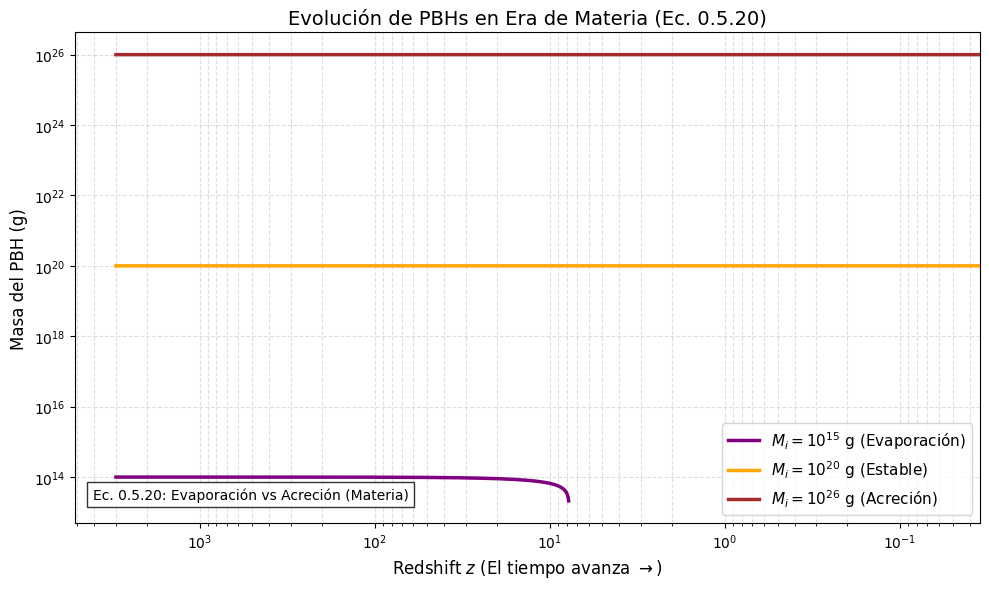

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
#SIN TERMINAR
# ---------------------------------------------------------
# 1. Constantes Físicas y Cosmológicas (CGS: cm, g, s)
# ---------------------------------------------------------
G = 6.67430e-8        # cm^3 g^-1 s^-2
c = 2.99792e10        # cm/s
hbar = 1.05457e-27    # erg s

# Constantes Cosmológicas
H0_km_s_Mpc = 67.4    
H0 = (H0_km_s_Mpc * 1e5) / 3.086e24  # H0 en 1/s
Omega_m0 = 0.315      # Densidad de materia actual

# Velocidad del medio (v_inf) en Era de Materia
# A diferencia de la radiación (c/sqrt(3)), aquí la velocidad es mucho menor 
# (gas frío o materia oscura). Usamos 10 km/s como valor representativo.
v_inf = 10.0 * 1e5   # 10 km/s en cm/s

# ---------------------------------------------------------
# 2. Ecuación Diferencial (0.5.20)
# ---------------------------------------------------------
def dMdz_matter(z, M):
    """
    Ecuación 0.5.20 del documento:
    dM/dz = [Término Evaporación] - [Término Acreción]
    """
    # Protección contra masa 0 o negativa
    if M <= 1.0 or np.isnan(M): return 0 
    
    # Pre-cálculos
    sqrt_Wm0 = np.sqrt(Omega_m0)
    term_z_evap = (1 + z)**2.5  # (1+z)^(5/2)
    term_z_acc  = np.sqrt(1 + z) # (1+z)^(1/2)
    
    # --- Término 1: Evaporación ---
    # Numerador: hbar * c^4
    # Denom: 3840 * pi * G^2 * M^2 * sqrt(Omega_m) * H0 * (1+z)^(5/2)
    num_evap = hbar * c**4
    den_evap = 3840 * np.pi * G**2 * M**2 * sqrt_Wm0 * H0 * term_z_evap
    term_evap = num_evap / den_evap
    
    # --- Término 2: Acreción (Materia) ---
    # Numerador: 3 * G * M^2 * sqrt(Omega_m) * H0 * sqrt(1+z)
    # Denom: 2 * v_inf^3
    num_acc = 3 * G * M**2 * sqrt_Wm0 * H0 * term_z_acc
    den_acc = 2 * v_inf**3
    term_acc = num_acc / den_acc
    
    return term_evap - term_acc

# ---------------------------------------------------------
# 3. Solucionador RK4
# ---------------------------------------------------------
def solve_rk4(func, z_start, z_end, M0, num_steps):
    z_values = np.linspace(z_start, z_end, num_steps)
    M_values = np.full(num_steps, np.nan) # Inicializar con NaN
    
    h = (z_end - z_start) / (num_steps - 1)
    
    M_values[0] = M0
    M = M0
    
    for i in range(num_steps - 1):
        z = z_values[i]
        
        # Si el agujero negro se evapora (< 1g), detenemos
        if M <= 1.0:
            break
            
        k1 = h * func(z, M)
        k2 = h * func(z + 0.5 * h, M + 0.5 * k1)
        k3 = h * func(z + 0.5 * h, M + 0.5 * k2)
        k4 = h * func(z + h, M + k3)
        
        M = M + (k1 + 2*k2 + 2*k3 + k4) / 6.0
        
        if M > 0:
            M_values[i+1] = M
        else:
            break
            
    return z_values, M_values

# ---------------------------------------------------------
# 4. Configuración y Gráfica
# ---------------------------------------------------------
# Rango de Redshift: Era de Materia (z=3000 hasta hoy z=0)
z_i = 3000.0
z_f = 0.0
steps = 50000

# Masas iniciales (Gramos)
# Seleccionamos masas que muestren los distintos regímenes en esta era
masas_iniciales_g = [1.0e14, 1.0e20, 1.0e26] 
colores = ['purple', 'orange', 'brown']
labels = [r'$M_i = 10^{15}$ g (Evaporación)', 
          r'$M_i = 10^{20}$ g (Estable)', 
          r'$M_i = 10^{26}$ g (Acreción)']

plt.figure(figsize=(10, 6))

for M_i, color, label in zip(masas_iniciales_g, colores, labels):
    z_sol, M_sol = solve_rk4(dMdz_matter, z_i, z_f, M_i, steps)
    
    plt.loglog(z_sol, M_sol, color=color, linewidth=2.5, label=label)

# Estética
plt.gca().invert_xaxis() # Tiempo avanza hacia la derecha (z disminuye)

plt.title(r'Evolución de PBHs en Era de Materia (Ec. 0.5.20)', fontsize=14)
plt.xlabel('Redshift $z$ (El tiempo avanza $\\rightarrow$)', fontsize=12)
plt.ylabel('Masa del PBH (g)', fontsize=12)
plt.grid(True, which="both", linestyle='--', alpha=0.4)
plt.legend(fontsize=11)

# Añadir nota de la ecuación
plt.text(0.02, 0.05, r'Ec. 0.5.20: Evaporación vs Acreción (Materia)', 
         transform=plt.gca().transAxes, fontsize=10, 
         bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()